# Swin-Only Robustness (FashionStyle14)

## Objective
Fine-tune **Swin-Base** (`swin_base_patch4_window7_224`) on **FashionStyle14** across **30 stratified random splits** (seeds from `seeds_list.txt`), with the same MLP head and training protocol as the image-only baselines.

## Pipeline
1. Load **30 seeds**, hyperparameters, and paths.
2. For **each seed**: 70% / 15% / 15% stratified split, train with early stopping, evaluate on test.
3. **Print and save** per-seed learning curves (`learning_curves.png`).
4. Aggregate **overall** test metrics (mean ± std) and **per-style** F1 (mean ± std).

## Outputs
**`results/image_only/swin/`**

| Per seed (`seed_<seed>/`) | Aggregated |
|---------------------------|------------|
| `best_model.pt` | `all_seeds_summary.csv` |
| `training_history.json` | `aggregation_summary.csv` |
| `learning_curves.png` | `per_class_metrics_summary.csv` |
| `test_metrics.json`, `per_class.csv` | |


## 1. Configuration, imports, and paths


In [1]:
from __future__ import annotations

import json
import os
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=UserWarning)

LEARNING_RATE = 5e-5
BATCH_SIZE = 32
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
MODEL_INIT_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

MODEL_NAME = "swin"
SWIN_MODEL_NAME = "swin_base_patch4_window7_224"

random.seed(MODEL_INIT_SEED)
np.random.seed(MODEL_INIT_SEED)
torch.manual_seed(MODEL_INIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def load_seeds(seeds_file: Path) -> List[int]:
    if not seeds_file.is_file():
        raise FileNotFoundError(f"Missing seeds file: {seeds_file}")
    content = seeds_file.read_text(encoding="utf-8")
    import re

    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    seeds = sorted({int(s) for s in matches if 1 <= int(s) <= 500})
    if len(seeds) != 30:
        print(f"Warning: expected 30 seeds, found {len(seeds)}")
    return seeds[:30]


def resolve_paths() -> Tuple[Path, Path, Path]:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "FusionStyle", cwd.parent / "FusionStyle"]
    for root in candidates:
        data_dir = root / "FashionStyle14_v1"
        dataset_dir = data_dir / "dataset"
        has_splits = (data_dir / "train.csv").is_file() or (data_dir / "train_new.csv").is_file()
        if has_splits and dataset_dir.is_dir():
            results_root = root / "results" / "image_only" / MODEL_NAME
            return root, data_dir, results_root
    raise FileNotFoundError(
        "Could not locate FashionStyle14_v1. Open the notebook from the repo root or FusionStyle/."
    )


PROJECT_ROOT, DATA_DIR, RESULTS_ROOT = resolve_paths()
IMAGE_ROOT = DATA_DIR
SEEDS_FILE = DATA_DIR / "seeds_list.txt"
COMPLETE_CSV = DATA_DIR / "complete_dataset.csv"
SEEDS = load_seeds(SEEDS_FILE)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("IMAGE_ROOT / dataset exists:", (IMAGE_ROOT / "dataset").is_dir())
print(f"Loaded {len(SEEDS)} seeds:", SEEDS)


/home/sandy/miniconda3/envs/fusionstyle/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /home/sandy/Document/FusionStyle
RESULTS_ROOT: /home/sandy/Document/FusionStyle/results/image_only/swin
IMAGE_ROOT / dataset exists: True
Loaded 30 seeds: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102, 112, 115, 120, 126, 141, 215, 217, 259, 280, 288, 303, 309, 328, 333, 347, 360, 367, 378, 380, 457]


## 2. Hardware check and runtime settings


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    total_mem_gb = props.total_memory / (1024**3)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {total_mem_gb:.2f} GB")
    # Reduce batch size on low-VRAM GPUs while keeping the notebook runnable
    if total_mem_gb < 8:
        BATCH_SIZE = 8
    elif total_mem_gb < 12:
        BATCH_SIZE = 16
    else:
        BATCH_SIZE = 32
else:
    print("CUDA not available; using CPU (training will be slow).")
    BATCH_SIZE = 8

print(f"Selected BATCH_SIZE: {BATCH_SIZE}")
print(f"Using AMP on CUDA: {use_amp}")


CUDA device: NVIDIA GeForce RTX 4060
Total GPU memory: 7.60 GB
Selected BATCH_SIZE: 8
Using AMP on CUDA: True


## 3. Load full dataset, labels, and stratified split helper


In [3]:
def normalize_rel_path(path_str: str) -> str:
    return str(path_str).strip().replace("\\", "/")


def load_complete_dataset(csv_path: Path) -> pd.DataFrame:
    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["style"] = df["rel_path"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].apply(lambda r: str((IMAGE_ROOT / r.replace("/", os.sep)).resolve()))
    df = df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)
    return df


df_full = load_complete_dataset(COMPLETE_CSV)
classes = sorted(df_full["style"].unique().tolist())
assert len(classes) == 14, f"Expected 14 classes, got {len(classes)}: {classes}"
style_to_idx = {s: i for i, s in enumerate(classes)}
num_classes = len(classes)

print("Full dataset size (existing files only):", len(df_full))
print("Number of classes:", num_classes)
print("Classes:", classes)
print(f"Data splits will be created per seed ({len(SEEDS)} experiments).")


def split_by_seed(df: pd.DataFrame, seed_value: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


Full dataset size (existing files only): 13212
Number of classes: 14
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Data splits will be created per seed (30 experiments).


## 4. PyTorch dataset and Swin transforms


In [4]:
class FashionImageDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, style_to_idx: Dict[str, int], transform):
        self.frame = frame.reset_index(drop=True)
        self.style_to_idx = style_to_idx
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.frame.iloc[idx]
        path = row["abs_path"]
        style = row["style"]
        label = self.style_to_idx[style]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), color=(0, 0, 0))
        tensor = self.transform(img)
        return {"pixel_values": tensor, "label": label}


def build_swin_transform():
    data_config = timm.data.resolve_data_config({}, model=SWIN_MODEL_NAME, verbose=False)
    return timm.data.create_transform(**data_config, is_training=False)


swin_transform = build_swin_transform()
NUM_WORKERS = 0


def make_loaders(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    transform,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    train_ds = FashionImageDataset(train_df, style_to_idx, transform)
    val_ds = FashionImageDataset(val_df, style_to_idx, transform)
    test_ds = FashionImageDataset(test_df, style_to_idx, transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader


print("Swin transform ready. Batch size:", BATCH_SIZE)


Swin transform ready. Batch size: 8


## 5. Swin model


In [5]:
class SwinImageClassifier(nn.Module):
    '''timm Swin backbone + MLP head (same pattern as other image-only models).'''

    def __init__(self, num_classes: int, dropout: float = DROPOUT):
        super().__init__()
        self.backbone = timm.create_model(SWIN_MODEL_NAME, pretrained=True, num_classes=0)
        in_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.backbone(x))


def build_swin_model() -> SwinImageClassifier:
    return SwinImageClassifier(num_classes=num_classes)


print("SwinImageClassifier defined.")


SwinImageClassifier defined.


## 6. Training, evaluation, and learning curves (saved to disk)


In [6]:
def evaluate(model: nn.Module, loader: DataLoader, criterion, device: torch.device, use_amp: bool) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    all_preds: List[int] = []
    all_labels: List[int] = []
    with torch.no_grad():
        for batch in loader:
            x = batch["pixel_values"].to(device, non_blocking=True)
            y = batch["label"].to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = model(x)
                loss = criterion(logits, y)
            total_loss += float(loss.item()) * y.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(y.cpu().numpy().tolist())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_p = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_r = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    metrics = {"loss": avg_loss, "accuracy": acc, "macro_precision": macro_p, "macro_recall": macro_r, "macro_f1": macro_f1}
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels)


def train_one_epoch(model, loader, optimizer, criterion, device, use_amp) -> Tuple[float, float]:
    model.train()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and device.type == "cuda")
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in loader:
        x = batch["pixel_values"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
            logits = model(x)
            loss = criterion(logits, y)
        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += float(loss.item()) * y.size(0)
        preds = logits.argmax(dim=1)
        correct += int((preds == y).sum().item())
        total += int(y.size(0))
    return total_loss / max(total, 1), correct / max(total, 1)


def plot_learning_curves(history: Dict[str, Any], title: str, save_path: Path | None = None) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(epochs, history["val_macro_f1"], label="val macro F1")
    axes[1].plot(epochs, history["train_acc"], label="train acc", alpha=0.7)
    axes[1].plot(epochs, history["val_acc"], label="val acc", alpha=0.7)
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved learning curves: {save_path}")
    plt.show()
    plt.close(fig)


def set_model_init_seed() -> None:
    random.seed(MODEL_INIT_SEED)
    np.random.seed(MODEL_INIT_SEED)
    torch.manual_seed(MODEL_INIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def train_image_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    out_dir: Path,
    seed_value: int,
    device: torch.device,
    use_amp: bool,
) -> Dict[str, Any]:
    out_dir.mkdir(parents=True, exist_ok=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "train_acc": [], "val_acc": []}
    best_f1 = -1.0
    best_state = None
    patience_left = EARLY_STOPPING_PATIENCE

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, use_amp)
        val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion, device, use_amp)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_metrics["accuracy"])
        print(
            f"  Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_metrics['accuracy']:.4f} macroF1 {val_metrics['macro_f1']:.4f}"
        )
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            patience_left = EARLY_STOPPING_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("  Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), out_dir / "best_model.pt")
    with open(out_dir / "training_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    curve_path = out_dir / "learning_curves.png"
    plot_learning_curves(history, title=f"Swin (seed {seed_value})", save_path=curve_path)

    _, test_metrics, test_preds, test_labels = evaluate(model, test_loader, criterion, device, use_amp)
    per_class_precision = precision_score(test_labels, test_preds, average=None, zero_division=0)
    per_class_recall = recall_score(test_labels, test_preds, average=None, zero_division=0)
    per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)

    per_class_rows = []
    for i, cls in enumerate(classes):
        per_class_rows.append({
            "class": cls,
            "acc": float(per_class_recall[i]),
            "precision": float(per_class_precision[i]),
            "recall": float(per_class_recall[i]),
            "f1": float(per_class_f1[i]),
        })
    per_class_df = pd.DataFrame(per_class_rows, columns=["class", "acc", "precision", "recall", "f1"])

    with open(out_dir / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)
    per_class_csv_path = out_dir / "per_class.csv"
    per_class_df.to_csv(per_class_csv_path, index=False, encoding="utf-8")

    print(f"\n[Swin | seed {seed_value}] Test metrics:", test_metrics)
    print(f"[Swin | seed {seed_value}] Per-class metrics (saved to {per_class_csv_path}):")
    print(per_class_df.to_string(index=False))

    return {"seed": seed_value, "test_metrics": test_metrics, "per_class_df": per_class_df}


def run_swin_robustness() -> pd.DataFrame:
    RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    rows: List[Dict[str, Any]] = []

    for seed_idx, seed_value in enumerate(SEEDS, start=1):
        seed_dir = RESULTS_ROOT / f"seed_{seed_value}"
        done_marker = seed_dir / "test_metrics.json"
        if done_marker.is_file():
            print(f"[Swin] Seed {seed_value} ({seed_idx}/{len(SEEDS)}): skip (already done)")
            with open(done_marker, encoding="utf-8") as f:
                cached = json.load(f)
            rows.append({"seed": seed_value, **cached})
            continue

        print("=" * 70)
        print(f"[Swin] Experiment {seed_idx}/{len(SEEDS)} | data split seed = {seed_value}")
        print("=" * 70)
        train_df, val_df, test_df = split_by_seed(df_full, seed_value)
        print(f"  Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
        train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, swin_transform)

        set_model_init_seed()
        model = build_swin_model().to(device)
        result = train_image_model(model, train_loader, val_loader, test_loader, seed_dir, seed_value, device, use_amp)
        rows.append({"seed": seed_value, **{k: float(v) for k, v in result["test_metrics"].items()}})

        del model, train_loader, val_loader, test_loader
        if device.type == "cuda":
            torch.cuda.empty_cache()

    summary_df = pd.DataFrame(rows)
    summary_path = RESULTS_ROOT / "all_seeds_summary.csv"
    summary_df.to_csv(summary_path, index=False, encoding="utf-8")
    print(f"\n[Swin] Saved per-seed summary: {summary_path}")
    return summary_df


def print_and_save_aggregates(summary_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]
    agg_rows = []
    print("\n" + "=" * 70)
    print("OVERALL TEST METRICS (mean +/- std across seeds)")
    print("=" * 70)
    for col in metric_cols:
        if col not in summary_df.columns:
            continue
        mean_v = float(summary_df[col].mean())
        std_v = float(summary_df[col].std())
        agg_rows.append({"metric": col, "mean": mean_v, "std": std_v})
        print(f"  {col}: {mean_v:.4f} +/- {std_v:.4f}")
    agg_df = pd.DataFrame(agg_rows)
    agg_path = RESULTS_ROOT / "aggregation_summary.csv"
    agg_df.to_csv(agg_path, index=False, encoding="utf-8")
    print(f"\nSaved: {agg_path}")

    per_class_rows = []
    for seed_value in SEEDS:
        pc_path = RESULTS_ROOT / f"seed_{seed_value}" / "per_class.csv"
        if not pc_path.is_file():
            continue
        pc = pd.read_csv(pc_path)
        for _, row in pc.iterrows():
            per_class_rows.append({
                "seed": seed_value,
                "style": row["class"],
                "f1": row["f1"],
                "precision": row["precision"],
                "recall": row["recall"],
                "acc": row["acc"],
            })
    if not per_class_rows:
        return agg_df, pd.DataFrame()

    pc_long = pd.DataFrame(per_class_rows)
    style_summary = []
    print("\n" + "=" * 70)
    print("PER-STYLE TEST F1 (mean +/- std across seeds)")
    print("=" * 70)
    for style, grp in pc_long.groupby("style"):
        f1_mean = float(grp["f1"].mean())
        f1_std = float(grp["f1"].std())
        style_summary.append({
            "style": style,
            "f1_mean": f1_mean,
            "f1_std": f1_std,
            "precision_mean": float(grp["precision"].mean()),
            "recall_mean": float(grp["recall"].mean()),
            "acc_mean": float(grp["acc"].mean()),
        })
        print(f"  {style:20s}  F1 {f1_mean:.4f} +/- {f1_std:.4f}")

    style_df = pd.DataFrame(style_summary).sort_values("style").reset_index(drop=True)
    style_path = RESULTS_ROOT / "per_class_metrics_summary.csv"
    style_df.to_csv(style_path, index=False, encoding="utf-8")
    print(f"\nSaved: {style_path}")
    return agg_df, style_df


print("Training utilities ready.")


Training utilities ready.


## 7. Run Swin robustness: 30 seeds


[Swin] Experiment 1/30 | data split seed = 13
  Split sizes: train=9248, val=1982, test=1982
  Epoch 01 | train loss 1.6304 acc 0.4709 | val loss 0.8452 acc 0.7296 macroF1 0.7240
  Epoch 02 | train loss 0.8973 acc 0.7327 | val loss 0.7510 acc 0.7649 macroF1 0.7649
  Epoch 03 | train loss 0.5978 acc 0.8271 | val loss 0.8395 acc 0.7447 macroF1 0.7459
  Epoch 04 | train loss 0.4262 acc 0.8824 | val loss 0.8314 acc 0.7664 macroF1 0.7678
  Epoch 05 | train loss 0.3063 acc 0.9177 | val loss 1.0548 acc 0.7422 macroF1 0.7401
  Epoch 06 | train loss 0.2596 acc 0.9316 | val loss 1.0618 acc 0.7563 macroF1 0.7585
  Epoch 07 | train loss 0.1997 acc 0.9506 | val loss 0.9522 acc 0.7836 macroF1 0.7850
  Epoch 08 | train loss 0.1939 acc 0.9477 | val loss 1.0965 acc 0.7644 macroF1 0.7615
  Epoch 09 | train loss 0.1541 acc 0.9596 | val loss 1.1789 acc 0.7629 macroF1 0.7582
  Epoch 10 | train loss 0.1322 acc 0.9667 | val loss 1.2592 acc 0.7664 macroF1 0.7655
  Epoch 11 | train loss 0.1254 acc 0.9675 | val

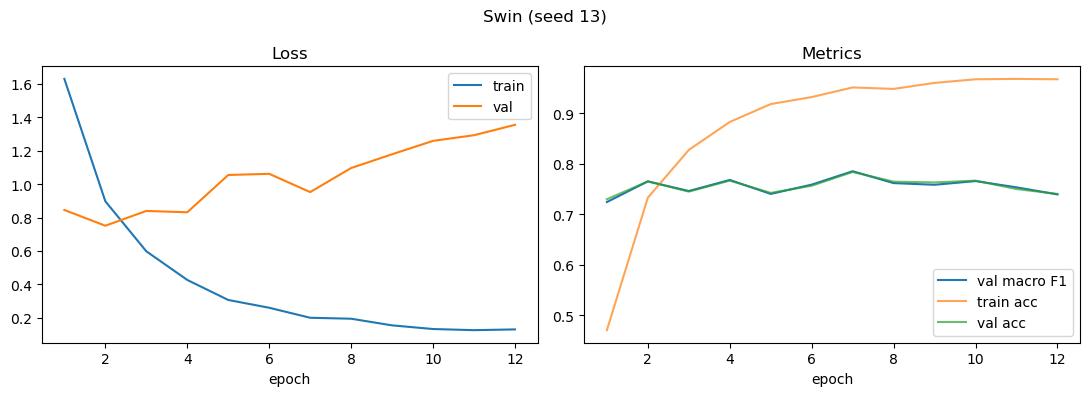


[Swin | seed 13] Test metrics: {'loss': 0.9827208519583394, 'accuracy': 0.7684157416750756, 'macro_precision': 0.7803131733167118, 'macro_recall': 0.771535022563681, 'macro_f1': 0.7701419083047686}
[Swin | seed 13] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_13/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.797101   0.582011 0.797101 0.672783
        dressy 0.940299   0.961832 0.940299 0.950943
        ethnic 0.751938   0.906542 0.751938 0.822034
         fairy 0.944444   0.964539 0.944444 0.954386
      feminine 0.851240   0.591954 0.851240 0.698305
           gal 0.692308   0.804878 0.692308 0.744361
       girlish 0.560241   0.592357 0.560241 0.575851
kireime-casual 0.563291   0.717742 0.563291 0.631206
        lolita 0.949686   0.949686 0.949686 0.949686
          mode 0.710692   0.763514 0.710692 0.736156
       natural 0.689922   0.839623 0.689922 0.757447
         retro 0.685039   0.783784 0.68

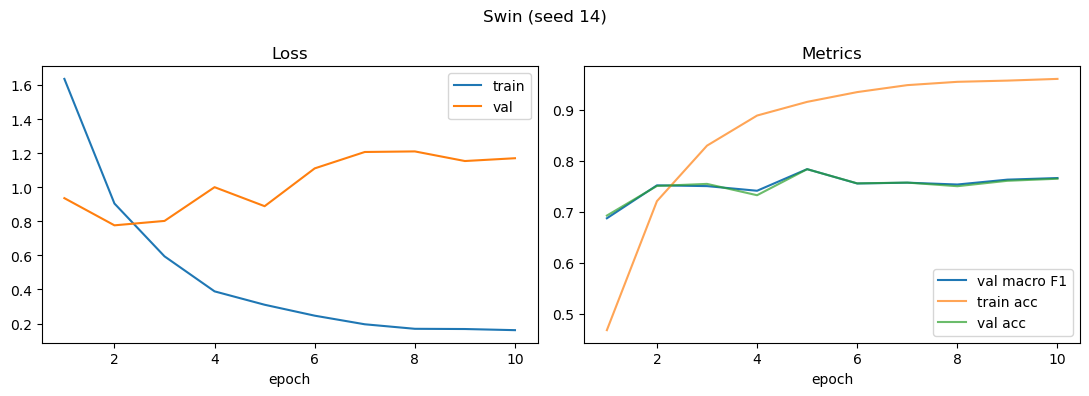


[Swin | seed 14] Test metrics: {'loss': 0.8727172474206757, 'accuracy': 0.7835519677093845, 'macro_precision': 0.7895961900644114, 'macro_recall': 0.7866566900306747, 'macro_f1': 0.7860248174968604}
[Swin | seed 14] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_14/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.688406   0.730769 0.688406 0.708955
        dressy 0.932836   0.946970 0.932836 0.939850
        ethnic 0.860465   0.798561 0.860465 0.828358
         fairy 0.944056   0.937500 0.944056 0.940767
      feminine 0.760331   0.779661 0.760331 0.769874
           gal 0.797203   0.802817 0.797203 0.800000
       girlish 0.590361   0.628205 0.590361 0.608696
kireime-casual 0.702532   0.623596 0.702532 0.660714
        lolita 0.918750   0.960784 0.918750 0.939297
          mode 0.779874   0.738095 0.779874 0.758410
       natural 0.751938   0.850877 0.751938 0.798354
         retro 0.755906   0.711111 0.7

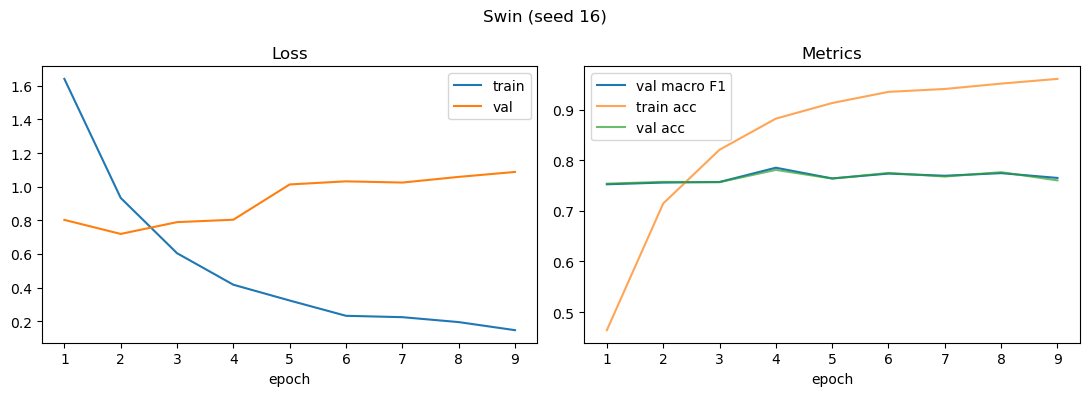


[Swin | seed 16] Test metrics: {'loss': 0.747917119312118, 'accuracy': 0.7880928355196771, 'macro_precision': 0.8064398040938113, 'macro_recall': 0.7894757562104907, 'macro_f1': 0.792451767105267}
[Swin | seed 16] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_16/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.751825   0.643750 0.751825 0.693603
        dressy 0.948148   0.969697 0.948148 0.958801
        ethnic 0.751938   0.822034 0.751938 0.785425
         fairy 0.972028   0.952055 0.972028 0.961938
      feminine 0.735537   0.747899 0.735537 0.741667
           gal 0.685315   0.867257 0.685315 0.765625
       girlish 0.716867   0.561321 0.716867 0.629630
kireime-casual 0.753165   0.601010 0.753165 0.668539
        lolita 0.955975   0.962025 0.955975 0.958991
          mode 0.698113   0.909836 0.698113 0.790036
       natural 0.751938   0.801653 0.751938 0.776000
         retro 0.740157   0.740157 0.740

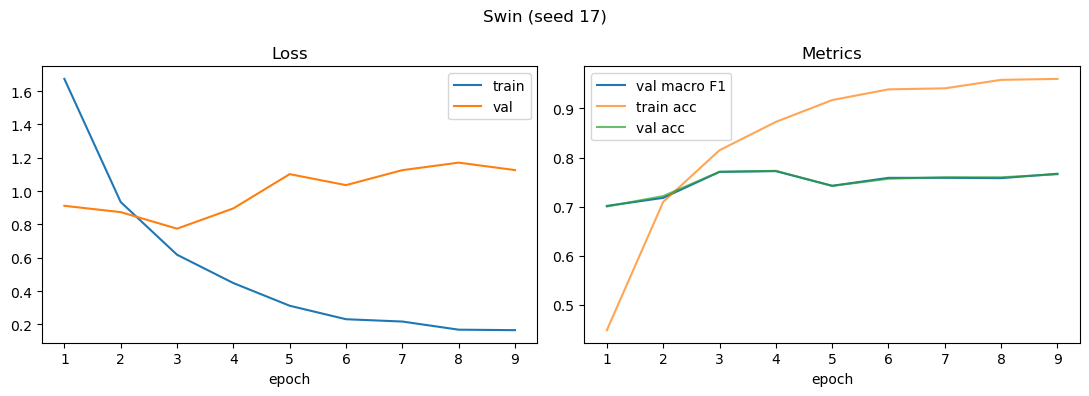


[Swin | seed 17] Test metrics: {'loss': 0.8195182511622442, 'accuracy': 0.7820383451059536, 'macro_precision': 0.7899374182314809, 'macro_recall': 0.7818272965982563, 'macro_f1': 0.7797159870899482}
[Swin | seed 17] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_17/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.702899   0.740458 0.702899 0.721190
        dressy 0.962963   0.921986 0.962963 0.942029
        ethnic 0.891473   0.782313 0.891473 0.833333
         fairy 0.986014   0.805714 0.986014 0.886792
      feminine 0.652893   0.790000 0.652893 0.714932
           gal 0.811189   0.698795 0.811189 0.750809
       girlish 0.554217   0.707692 0.554217 0.621622
kireime-casual 0.582278   0.766667 0.582278 0.661871
        lolita 0.930818   0.980132 0.930818 0.954839
          mode 0.924528   0.612500 0.924528 0.736842
       natural 0.720930   0.815789 0.720930 0.765432
         retro 0.692913   0.771930 0.6

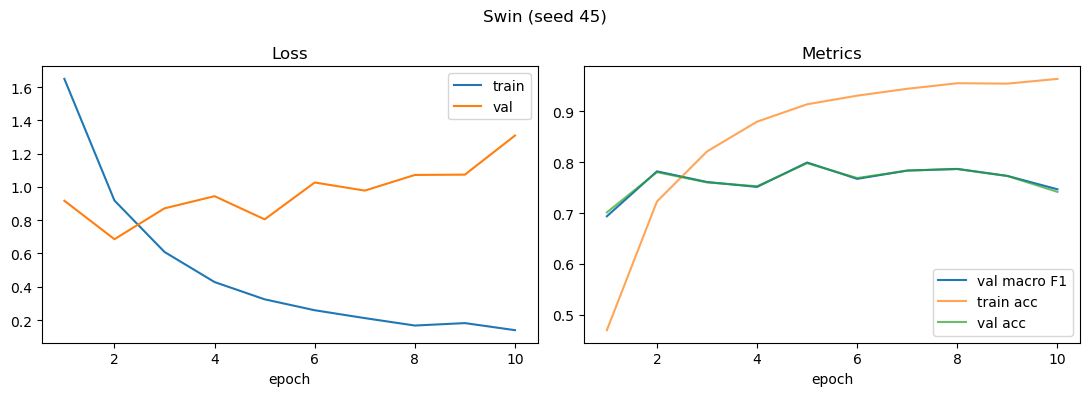


[Swin | seed 45] Test metrics: {'loss': 0.82732950432149, 'accuracy': 0.7961654894046418, 'macro_precision': 0.8014050400644622, 'macro_recall': 0.7950759796508573, 'macro_f1': 0.7963195549391192}
[Swin | seed 45] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_45/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.760870   0.729167 0.760870 0.744681
        dressy 0.955224   0.955224 0.955224 0.955224
        ethnic 0.674419   0.878788 0.674419 0.763158
         fairy 0.923077   0.936170 0.923077 0.929577
      feminine 0.809917   0.736842 0.809917 0.771654
           gal 0.783217   0.842105 0.783217 0.811594
       girlish 0.698795   0.637363 0.698795 0.666667
kireime-casual 0.727848   0.664740 0.727848 0.694864
        lolita 0.968750   0.922619 0.968750 0.945122
          mode 0.761006   0.801325 0.761006 0.780645
       natural 0.744186   0.842105 0.744186 0.790123
         retro 0.661417   0.711864 0.661

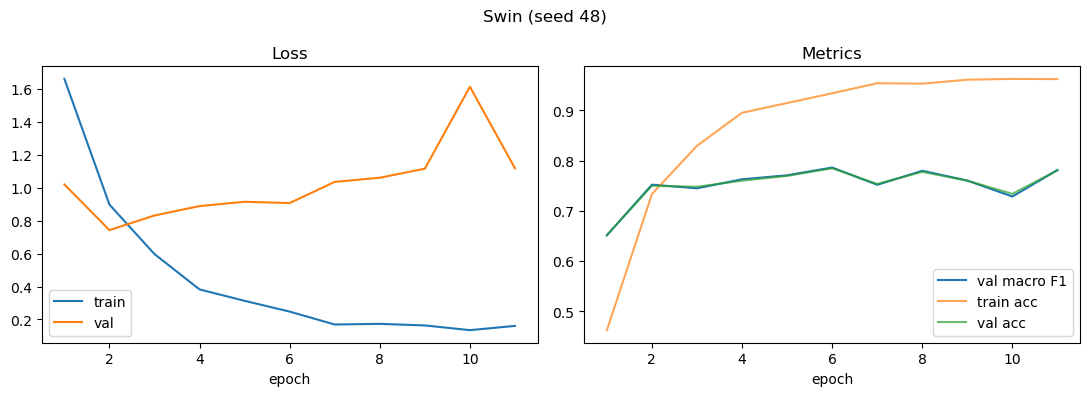


[Swin | seed 48] Test metrics: {'loss': 0.9239101040014466, 'accuracy': 0.7901109989909183, 'macro_precision': 0.7997451334735944, 'macro_recall': 0.78815998902618, 'macro_f1': 0.7901434831635061}
[Swin | seed 48] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_48/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.572464   0.782178 0.572464 0.661088
        dressy 0.962963   0.942029 0.962963 0.952381
        ethnic 0.821705   0.796992 0.821705 0.809160
         fairy 0.881119   0.933333 0.881119 0.906475
      feminine 0.644628   0.829787 0.644628 0.725581
           gal 0.811189   0.748387 0.811189 0.778523
       girlish 0.734940   0.645503 0.734940 0.687324
kireime-casual 0.683544   0.650602 0.683544 0.666667
        lolita 0.950000   0.944099 0.950000 0.947040
          mode 0.836478   0.711230 0.836478 0.768786
       natural 0.744186   0.813559 0.744186 0.777328
         retro 0.826772   0.664557 0.826

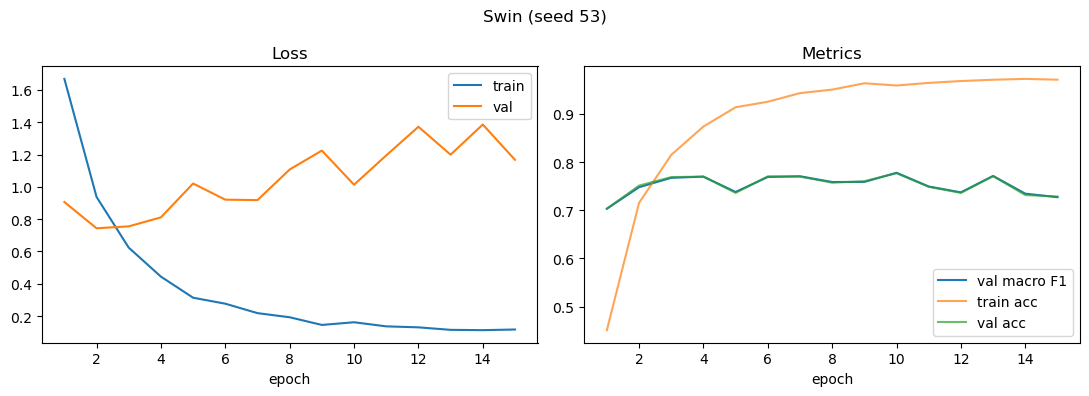


[Swin | seed 53] Test metrics: {'loss': 0.9724527502396754, 'accuracy': 0.7946518668012109, 'macro_precision': 0.8011299471880012, 'macro_recall': 0.7945163634087826, 'macro_f1': 0.7956361181466136}
[Swin | seed 53] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_53/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.700730   0.676056 0.700730 0.688172
        dressy 0.970370   0.935714 0.970370 0.952727
        ethnic 0.829457   0.884298 0.829457 0.856000
         fairy 0.944056   0.964286 0.944056 0.954064
      feminine 0.611570   0.813187 0.611570 0.698113
           gal 0.790210   0.784722 0.790210 0.787456
       girlish 0.650602   0.545455 0.650602 0.593407
kireime-casual 0.588608   0.694030 0.588608 0.636986
        lolita 0.975000   0.945455 0.975000 0.960000
          mode 0.798742   0.858108 0.798742 0.827362
       natural 0.813953   0.833333 0.813953 0.823529
         retro 0.771654   0.666667 0.7

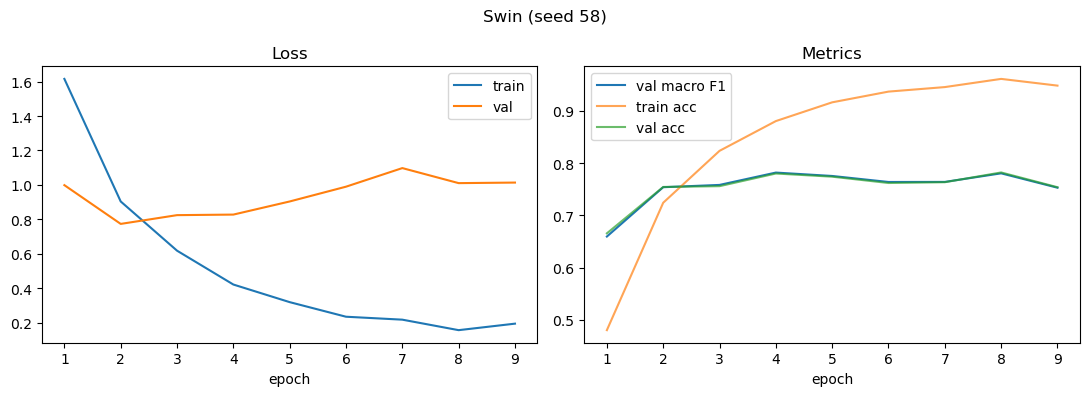


[Swin | seed 58] Test metrics: {'loss': 0.8506928922309644, 'accuracy': 0.7800201816347124, 'macro_precision': 0.7905822018756506, 'macro_recall': 0.7796043684150583, 'macro_f1': 0.781139340416057}
[Swin | seed 58] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_58/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.739130   0.684564 0.739130 0.710801
        dressy 0.947761   0.933824 0.947761 0.940741
        ethnic 0.790698   0.816000 0.790698 0.803150
         fairy 0.923077   0.936170 0.923077 0.929577
      feminine 0.710744   0.834951 0.710744 0.767857
           gal 0.699301   0.813008 0.699301 0.751880
       girlish 0.584337   0.678322 0.584337 0.627832
kireime-casual 0.677215   0.652439 0.677215 0.664596
        lolita 0.943750   0.980519 0.943750 0.961783
          mode 0.880503   0.666667 0.880503 0.758808
       natural 0.658915   0.833333 0.658915 0.735931
         retro 0.795276   0.594118 0.79

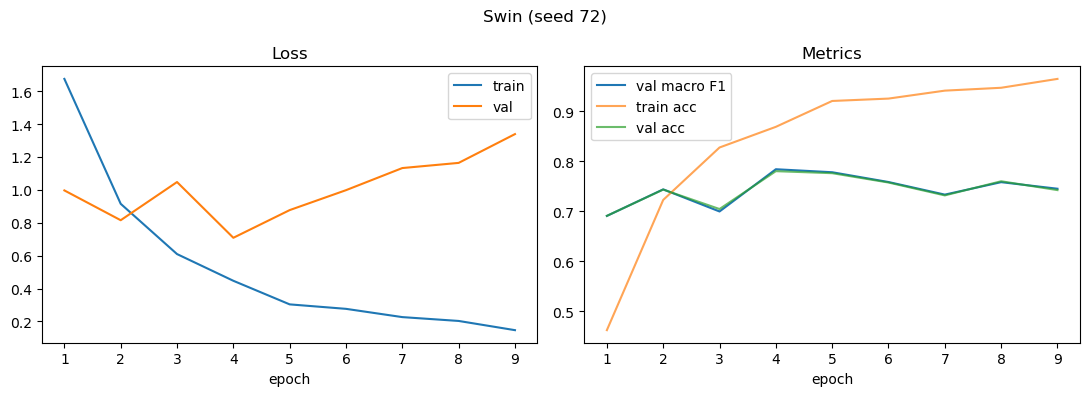


[Swin | seed 72] Test metrics: {'loss': 0.672623533082658, 'accuracy': 0.7855701311806257, 'macro_precision': 0.7959138801216016, 'macro_recall': 0.7826549985913124, 'macro_f1': 0.7870723848969904}
[Swin | seed 72] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_72/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.688406   0.633333 0.688406 0.659722
        dressy 0.917910   0.938931 0.917910 0.928302
        ethnic 0.829457   0.877049 0.829457 0.852590
         fairy 0.923611   0.904762 0.923611 0.914089
      feminine 0.636364   0.785714 0.636364 0.703196
           gal 0.804196   0.815603 0.804196 0.809859
       girlish 0.686747   0.616216 0.686747 0.649573
kireime-casual 0.702532   0.566327 0.702532 0.627119
        lolita 0.956250   0.938650 0.956250 0.947368
          mode 0.811321   0.801242 0.811321 0.806250
       natural 0.651163   0.823529 0.651163 0.727273
         retro 0.724409   0.793103 0.72

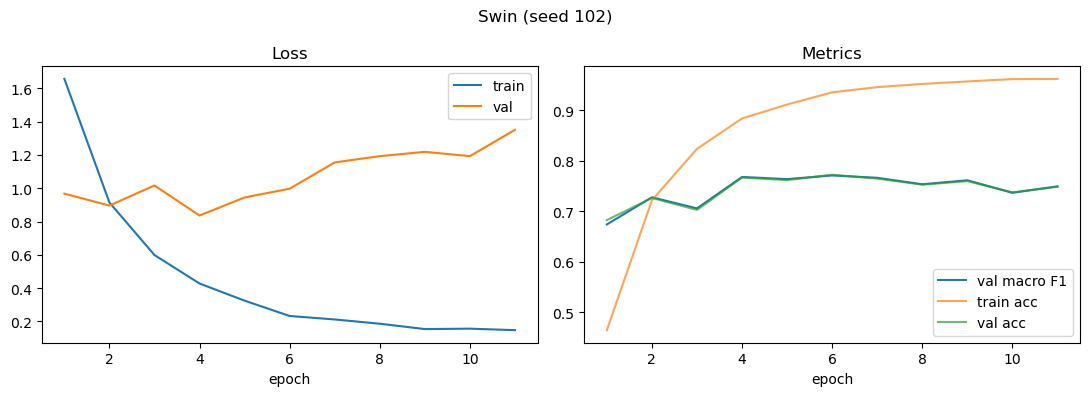


[Swin | seed 102] Test metrics: {'loss': 0.9834961559168626, 'accuracy': 0.7734611503531786, 'macro_precision': 0.7767157534103198, 'macro_recall': 0.7759917324062879, 'macro_f1': 0.7722855201850333}
[Swin | seed 102] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_102/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.768116   0.670886 0.768116 0.716216
        dressy 0.925373   0.939394 0.925373 0.932331
        ethnic 0.914729   0.797297 0.914729 0.851986
         fairy 0.979167   0.915584 0.979167 0.946309
      feminine 0.636364   0.747573 0.636364 0.687500
           gal 0.797203   0.678571 0.797203 0.733119
       girlish 0.451807   0.694444 0.451807 0.547445
kireime-casual 0.727848   0.611702 0.727848 0.664740
        lolita 0.931250   0.955128 0.931250 0.943038
          mode 0.704403   0.777778 0.704403 0.739274
       natural 0.720930   0.815789 0.720930 0.765432
         retro 0.763780   0.668966 

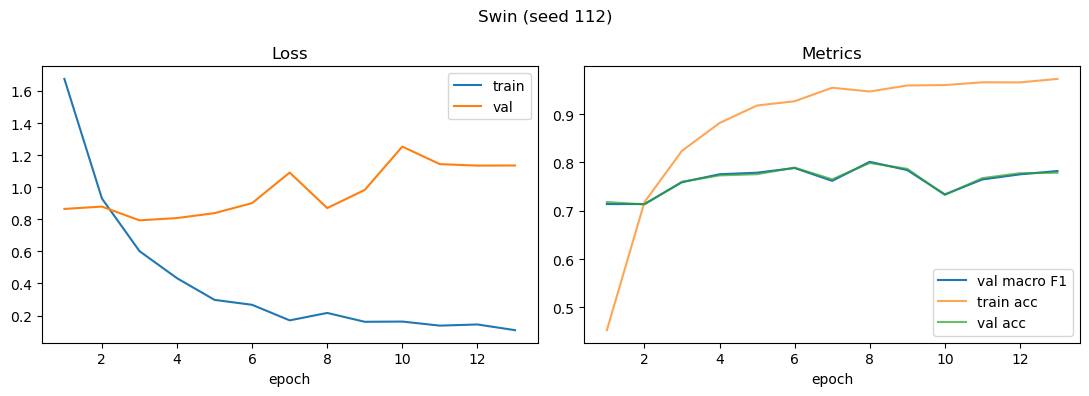


[Swin | seed 112] Test metrics: {'loss': 0.9404660823682603, 'accuracy': 0.7820383451059536, 'macro_precision': 0.7910410593222457, 'macro_recall': 0.7826472325355367, 'macro_f1': 0.7845965659747615}
[Swin | seed 112] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_112/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.775362   0.652439 0.775362 0.708609
        dressy 0.940299   0.954545 0.940299 0.947368
        ethnic 0.806202   0.852459 0.806202 0.828685
         fairy 0.909091   0.948905 0.909091 0.928571
      feminine 0.793388   0.750000 0.793388 0.771084
           gal 0.769231   0.743243 0.769231 0.756014
       girlish 0.596386   0.651316 0.596386 0.622642
kireime-casual 0.683544   0.606742 0.683544 0.642857
        lolita 0.943750   0.974194 0.943750 0.958730
          mode 0.849057   0.710526 0.849057 0.773639
       natural 0.697674   0.873786 0.697674 0.775862
         retro 0.669291   0.745614 

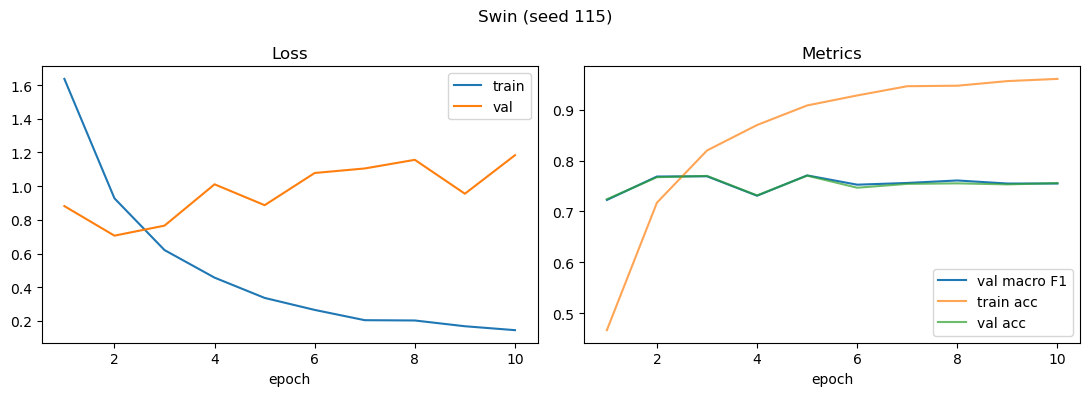


[Swin | seed 115] Test metrics: {'loss': 0.9555486963929583, 'accuracy': 0.7618567103935419, 'macro_precision': 0.7812972368058249, 'macro_recall': 0.7609014631560386, 'macro_f1': 0.7616213720014754}
[Swin | seed 115] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_115/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.550725   0.730769 0.550725 0.628099
        dressy 0.962687   0.962687 0.962687 0.962687
        ethnic 0.922481   0.619792 0.922481 0.741433
         fairy 0.868056   0.954198 0.868056 0.909091
      feminine 0.677686   0.863158 0.677686 0.759259
           gal 0.846154   0.737805 0.846154 0.788274
       girlish 0.590361   0.653333 0.590361 0.620253
kireime-casual 0.734177   0.529680 0.734177 0.615385
        lolita 0.968750   0.950920 0.968750 0.959752
          mode 0.798742   0.760479 0.798742 0.779141
       natural 0.550388   0.887500 0.550388 0.679426
         retro 0.653543   0.703390 

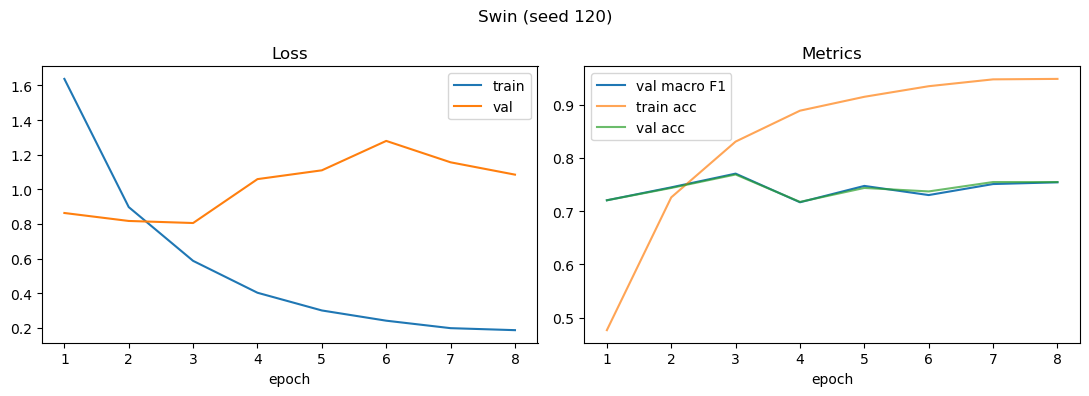


[Swin | seed 120] Test metrics: {'loss': 0.7737221769559997, 'accuracy': 0.777497477295661, 'macro_precision': 0.7823491706278077, 'macro_recall': 0.7798610939723869, 'macro_f1': 0.7762594162835471}
[Swin | seed 120] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_120/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.760870   0.724138 0.760870 0.742049
        dressy 0.962687   0.948529 0.962687 0.955556
        ethnic 0.627907   0.843750 0.627907 0.720000
         fairy 0.868056   0.912409 0.868056 0.889680
      feminine 0.768595   0.704545 0.768595 0.735178
           gal 0.685315   0.823529 0.685315 0.748092
       girlish 0.608434   0.677852 0.608434 0.641270
kireime-casual 0.594937   0.740157 0.594937 0.659649
        lolita 0.981250   0.892045 0.981250 0.934524
          mode 0.773585   0.778481 0.773585 0.776025
       natural 0.875969   0.660819 0.875969 0.753333
         retro 0.803150   0.603550 0

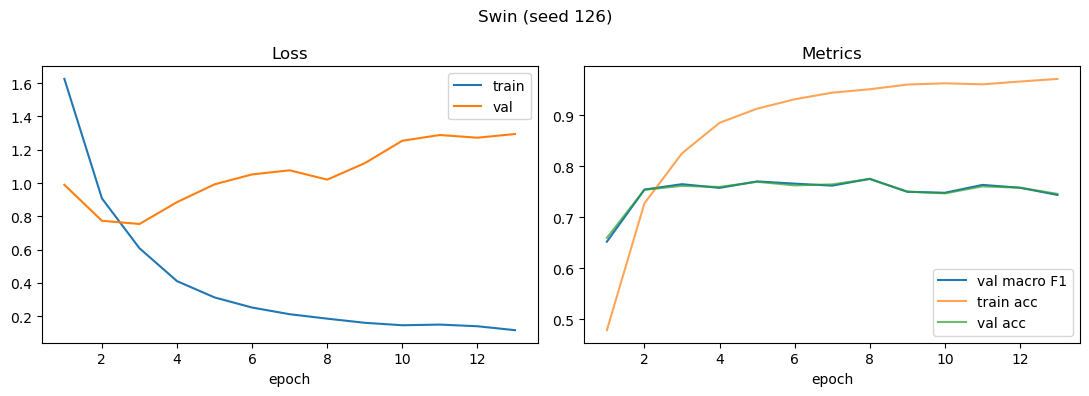


[Swin | seed 126] Test metrics: {'loss': 0.9641421323888357, 'accuracy': 0.7764883955600403, 'macro_precision': 0.7770570737850472, 'macro_recall': 0.777837430891421, 'macro_f1': 0.7754387946913155}
[Swin | seed 126] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_126/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.664234   0.739837 0.664234 0.700000
        dressy 0.955556   0.977273 0.955556 0.966292
        ethnic 0.837209   0.837209 0.837209 0.837209
         fairy 0.972222   0.838323 0.972222 0.900322
      feminine 0.760331   0.605263 0.760331 0.673993
           gal 0.783217   0.777778 0.783217 0.780488
       girlish 0.506024   0.641221 0.506024 0.565657
kireime-casual 0.664557   0.652174 0.664557 0.658307
        lolita 0.968750   0.950920 0.968750 0.959752
          mode 0.773585   0.715116 0.773585 0.743202
       natural 0.744186   0.820513 0.744186 0.780488
         retro 0.700787   0.689922 0

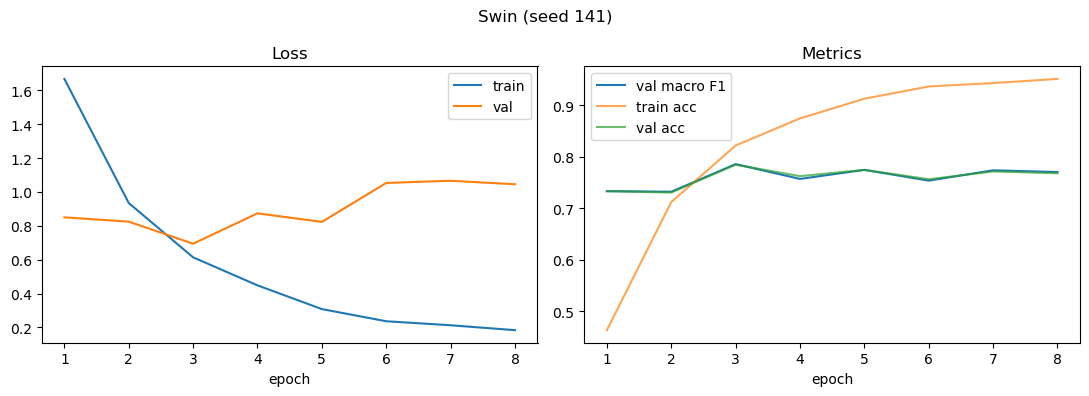


[Swin | seed 141] Test metrics: {'loss': 0.7166540372503994, 'accuracy': 0.7790110998990918, 'macro_precision': 0.7849592592750783, 'macro_recall': 0.7819093125103557, 'macro_f1': 0.7806383951590691}
[Swin | seed 141] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_141/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.700730   0.727273 0.700730 0.713755
        dressy 0.918519   0.932331 0.918519 0.925373
        ethnic 0.806202   0.825397 0.806202 0.815686
         fairy 0.888112   0.969466 0.888112 0.927007
      feminine 0.735537   0.773913 0.735537 0.754237
           gal 0.783217   0.811594 0.783217 0.797153
       girlish 0.644578   0.581522 0.644578 0.611429
kireime-casual 0.588608   0.726562 0.588608 0.650350
        lolita 0.975000   0.912281 0.975000 0.942598
          mode 0.735849   0.785235 0.735849 0.759740
       natural 0.790698   0.772727 0.790698 0.781609
         retro 0.771654   0.640523 

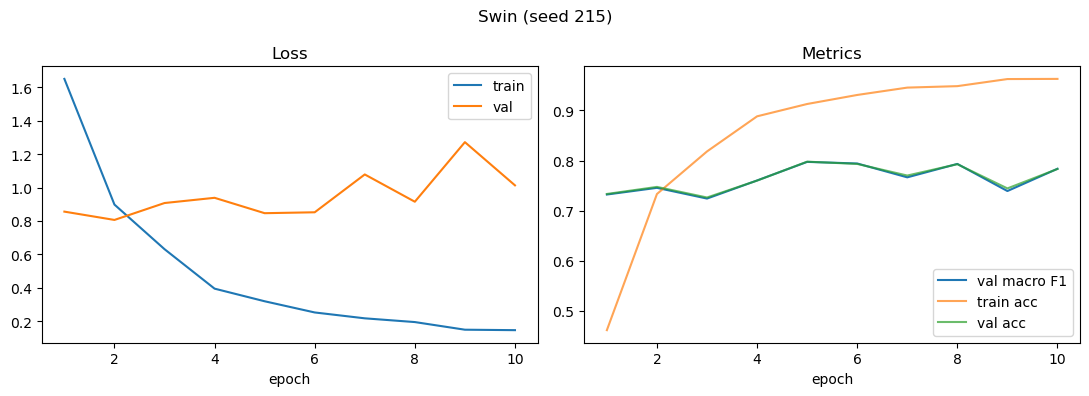


[Swin | seed 215] Test metrics: {'loss': 0.9350135659594108, 'accuracy': 0.7835519677093845, 'macro_precision': 0.7930212169448642, 'macro_recall': 0.7860019204151957, 'macro_f1': 0.7848940190035415}
[Swin | seed 215] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_215/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.751825   0.668831 0.751825 0.707904
        dressy 0.843284   0.982609 0.843284 0.907631
        ethnic 0.829457   0.816794 0.829457 0.823077
         fairy 0.972222   0.921053 0.972222 0.945946
      feminine 0.677686   0.854167 0.677686 0.755760
           gal 0.699301   0.909091 0.699301 0.790514
       girlish 0.650602   0.596685 0.650602 0.622478
kireime-casual 0.607595   0.716418 0.607595 0.657534
        lolita 0.968553   0.911243 0.968553 0.939024
          mode 0.691824   0.785714 0.691824 0.735786
       natural 0.829457   0.748252 0.829457 0.786765
         retro 0.755906   0.666667 

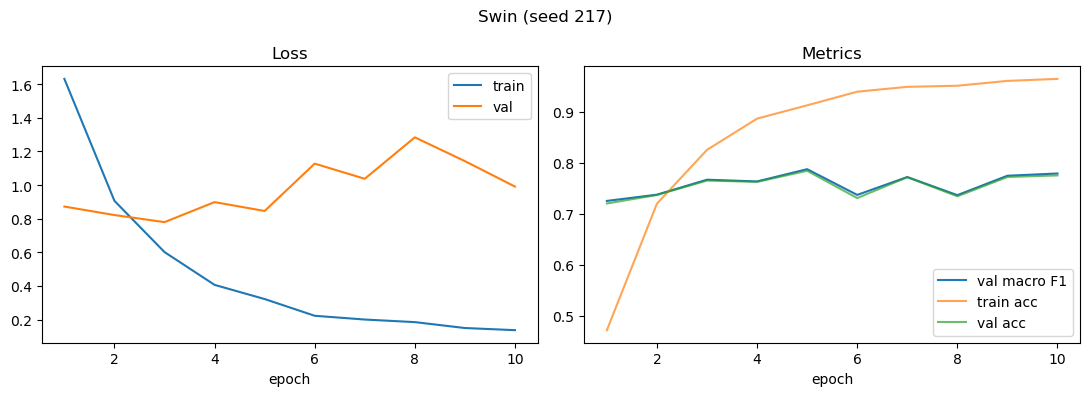


[Swin | seed 217] Test metrics: {'loss': 0.8177918797184072, 'accuracy': 0.7996972754793138, 'macro_precision': 0.8094974862877095, 'macro_recall': 0.8020199186803342, 'macro_f1': 0.8005767266066375}
[Swin | seed 217] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_217/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.620438   0.841584 0.620438 0.714286
        dressy 0.888889   0.975610 0.888889 0.930233
        ethnic 0.852713   0.839695 0.852713 0.846154
         fairy 0.944444   0.912752 0.944444 0.928328
      feminine 0.892562   0.620690 0.892562 0.732203
           gal 0.741259   0.815385 0.741259 0.776557
       girlish 0.590361   0.736842 0.590361 0.655518
kireime-casual 0.727848   0.621622 0.727848 0.670554
        lolita 0.987421   0.923529 0.987421 0.954407
          mode 0.861635   0.761111 0.861635 0.808260
       natural 0.782946   0.808000 0.782946 0.795276
         retro 0.779528   0.702128 

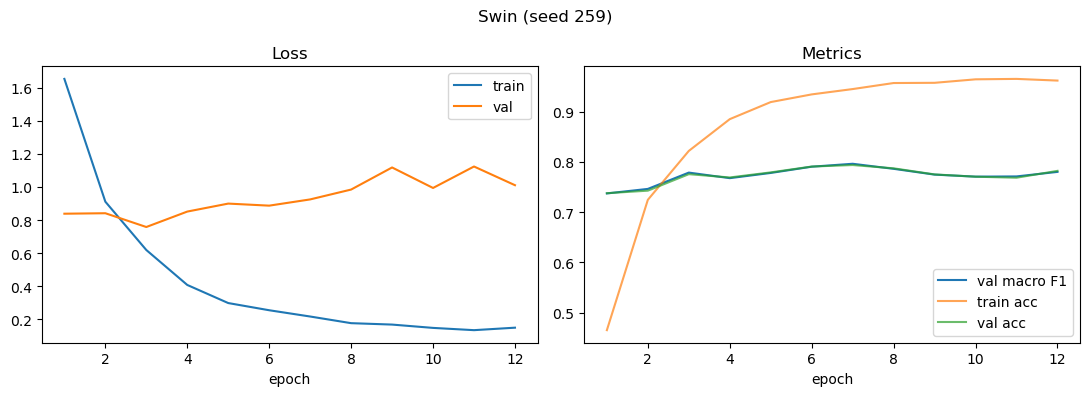


[Swin | seed 259] Test metrics: {'loss': 1.1148783320976434, 'accuracy': 0.7578203834510595, 'macro_precision': 0.7809606821888359, 'macro_recall': 0.7564873260871584, 'macro_f1': 0.7588336407906332}
[Swin | seed 259] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_259/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.608696   0.717949 0.608696 0.658824
        dressy 0.918519   0.984127 0.918519 0.950192
        ethnic 0.782946   0.808000 0.782946 0.795276
         fairy 0.867133   0.961240 0.867133 0.911765
      feminine 0.826446   0.606061 0.826446 0.699301
           gal 0.769231   0.758621 0.769231 0.763889
       girlish 0.692771   0.542453 0.692771 0.608466
kireime-casual 0.765823   0.576190 0.765823 0.657609
        lolita 1.000000   0.903955 1.000000 0.949555
          mode 0.534591   0.913978 0.534591 0.674603
       natural 0.589147   0.791667 0.589147 0.675556
         retro 0.614173   0.857143 

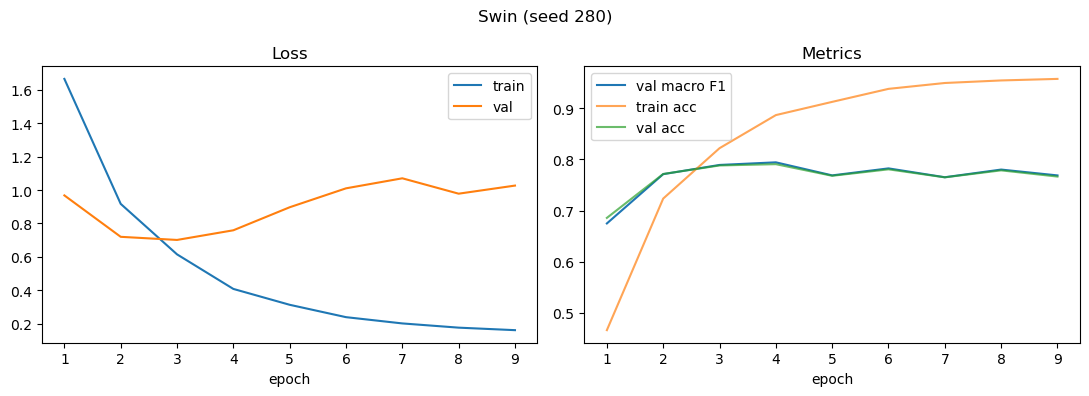


[Swin | seed 280] Test metrics: {'loss': 0.7585069782558291, 'accuracy': 0.7865792129162462, 'macro_precision': 0.7960939215493995, 'macro_recall': 0.7874041463800834, 'macro_f1': 0.7894990151749168}
[Swin | seed 280] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_280/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.775362   0.699346 0.775362 0.735395
        dressy 0.955556   0.969925 0.955556 0.962687
        ethnic 0.821705   0.883333 0.821705 0.851406
         fairy 0.895105   0.934307 0.895105 0.914286
      feminine 0.719008   0.674419 0.719008 0.696000
           gal 0.720280   0.830645 0.720280 0.771536
       girlish 0.644578   0.604520 0.644578 0.623907
kireime-casual 0.664557   0.593220 0.664557 0.626866
        lolita 0.962264   0.956250 0.962264 0.959248
          mode 0.817610   0.783133 0.817610 0.800000
       natural 0.837209   0.710526 0.837209 0.768683
         retro 0.685039   0.828571 

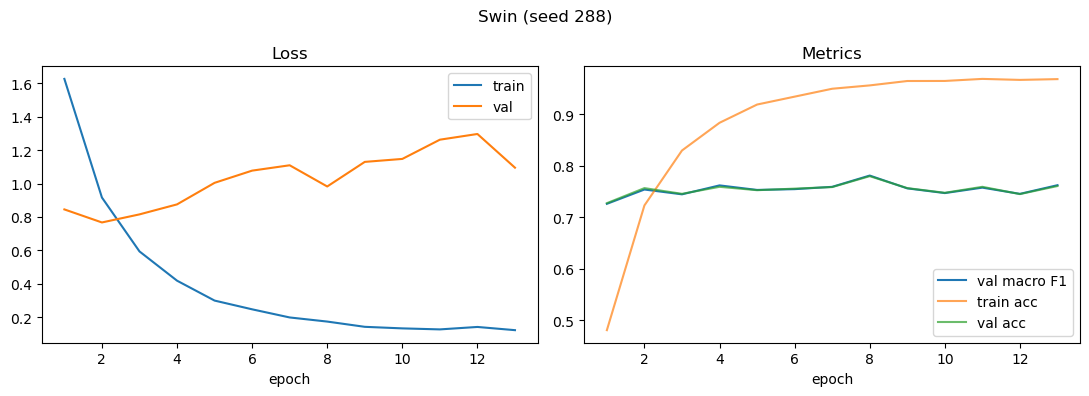


[Swin | seed 288] Test metrics: {'loss': 0.9902186014216795, 'accuracy': 0.7674066599394551, 'macro_precision': 0.7839601530500844, 'macro_recall': 0.7646082289711186, 'macro_f1': 0.769480087474941}
[Swin | seed 288] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_288/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.673913   0.738095 0.673913 0.704545
        dressy 0.874074   0.975207 0.874074 0.921875
        ethnic 0.689922   0.917526 0.689922 0.787611
         fairy 0.902778   0.878378 0.902778 0.890411
      feminine 0.619835   0.797872 0.619835 0.697674
           gal 0.790210   0.773973 0.790210 0.782007
       girlish 0.746988   0.543860 0.746988 0.629442
kireime-casual 0.632911   0.645161 0.632911 0.638978
        lolita 0.937107   0.919753 0.937107 0.928349
          mode 0.754717   0.759494 0.754717 0.757098
       natural 0.782946   0.770992 0.782946 0.776923
         retro 0.637795   0.818182 0

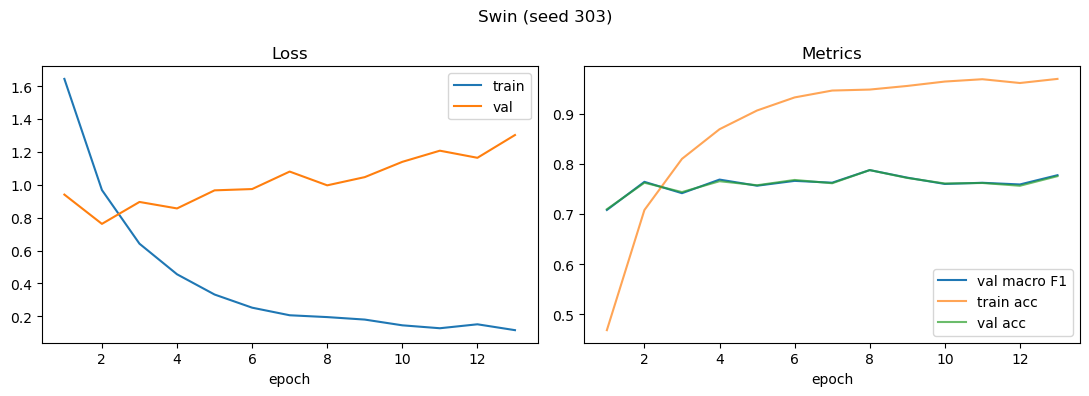


[Swin | seed 303] Test metrics: {'loss': 0.9549555242302199, 'accuracy': 0.7830474268415741, 'macro_precision': 0.7883489951649268, 'macro_recall': 0.7846027424924636, 'macro_f1': 0.7846310575854334}
[Swin | seed 303] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_303/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.715328   0.685315 0.715328 0.700000
        dressy 0.902985   0.937984 0.902985 0.920152
        ethnic 0.860465   0.792857 0.860465 0.825279
         fairy 0.916667   0.929577 0.916667 0.923077
      feminine 0.694215   0.831683 0.694215 0.756757
           gal 0.699301   0.819672 0.699301 0.754717
       girlish 0.560241   0.641379 0.560241 0.598071
kireime-casual 0.702532   0.634286 0.702532 0.666667
        lolita 0.956250   0.962264 0.956250 0.959248
          mode 0.723270   0.727848 0.723270 0.725552
       natural 0.813953   0.826772 0.813953 0.820312
         retro 0.771654   0.753846 

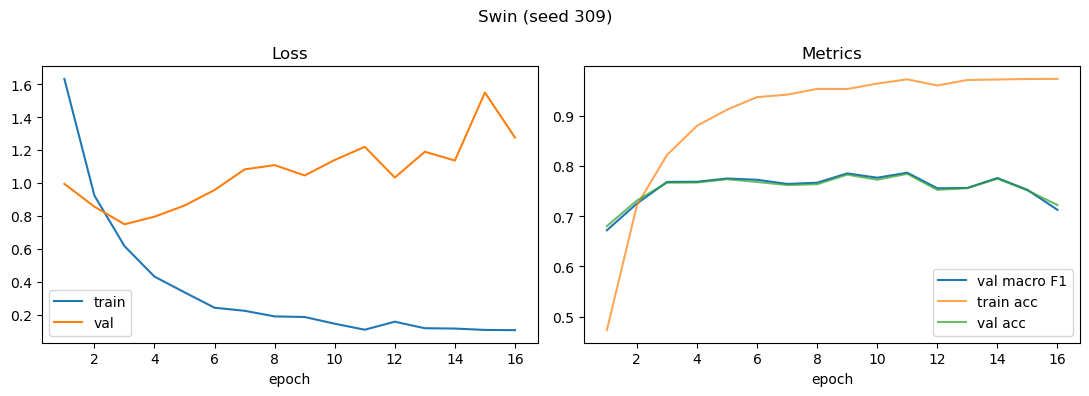


[Swin | seed 309] Test metrics: {'loss': 1.1724860635703556, 'accuracy': 0.7901109989909183, 'macro_precision': 0.7985970803263782, 'macro_recall': 0.7911960372844783, 'macro_f1': 0.7930083208947264}
[Swin | seed 309] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_309/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.759124   0.662420 0.759124 0.707483
        dressy 0.911111   0.984000 0.911111 0.946154
        ethnic 0.844961   0.844961 0.844961 0.844961
         fairy 0.951049   0.951049 0.951049 0.951049
      feminine 0.768595   0.794872 0.768595 0.781513
           gal 0.748252   0.856000 0.748252 0.798507
       girlish 0.596386   0.660000 0.596386 0.626582
kireime-casual 0.721519   0.561576 0.721519 0.631579
        lolita 0.962264   0.938650 0.962264 0.950311
          mode 0.792453   0.797468 0.792453 0.794953
       natural 0.860465   0.787234 0.860465 0.822222
         retro 0.661417   0.736842 

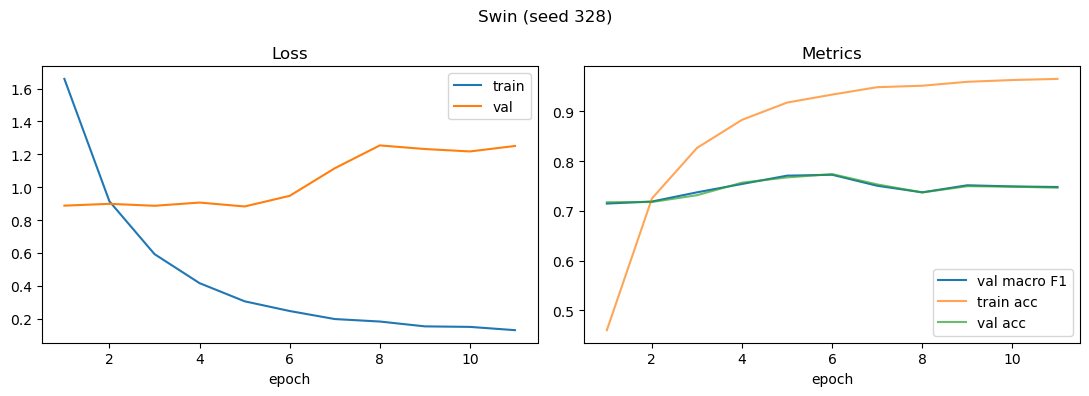


[Swin | seed 328] Test metrics: {'loss': 0.9008875631179386, 'accuracy': 0.7815338042381433, 'macro_precision': 0.7852816594399284, 'macro_recall': 0.7818480188756454, 'macro_f1': 0.7802818589896986}
[Swin | seed 328] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_328/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.795620   0.619318 0.795620 0.696486
        dressy 0.977612   0.867550 0.977612 0.919298
        ethnic 0.813953   0.889831 0.813953 0.850202
         fairy 0.965278   0.868750 0.965278 0.914474
      feminine 0.694215   0.724138 0.694215 0.708861
           gal 0.790210   0.768707 0.790210 0.779310
       girlish 0.626506   0.697987 0.626506 0.660317
kireime-casual 0.664557   0.640244 0.664557 0.652174
        lolita 0.931250   0.955128 0.931250 0.943038
          mode 0.729560   0.773333 0.729560 0.750809
       natural 0.713178   0.859813 0.713178 0.779661
         retro 0.582677   0.770833 

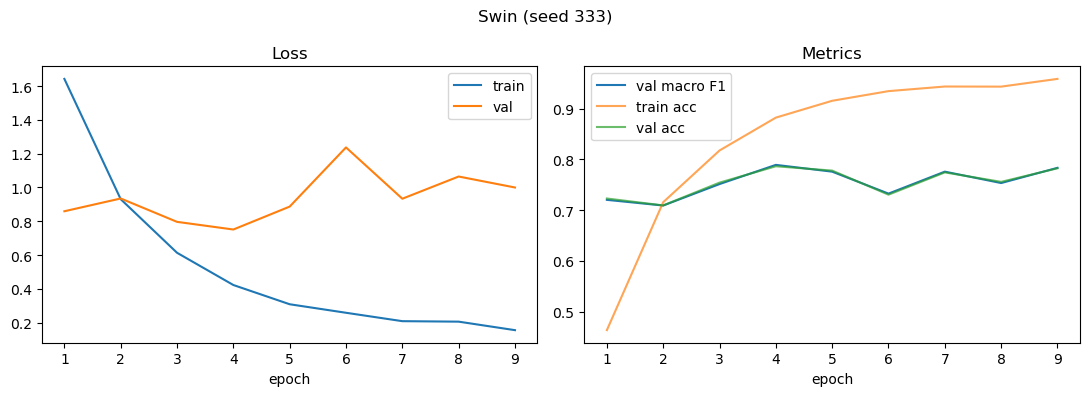


[Swin | seed 333] Test metrics: {'loss': 0.7692641147330599, 'accuracy': 0.777497477295661, 'macro_precision': 0.7926192611333569, 'macro_recall': 0.7755605370364578, 'macro_f1': 0.7787431323966336}
[Swin | seed 333] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_333/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.795620   0.589189 0.795620 0.677019
        dressy 0.955556   0.977273 0.955556 0.966292
        ethnic 0.829457   0.804511 0.829457 0.816794
         fairy 0.951049   0.900662 0.951049 0.925170
      feminine 0.776860   0.740157 0.776860 0.758065
           gal 0.720280   0.851240 0.720280 0.780303
       girlish 0.740964   0.591346 0.740964 0.657754
kireime-casual 0.569620   0.566038 0.569620 0.567823
        lolita 0.955975   0.955975 0.955975 0.955975
          mode 0.786164   0.786164 0.786164 0.786164
       natural 0.751938   0.815126 0.751938 0.782258
         retro 0.527559   0.797619 0

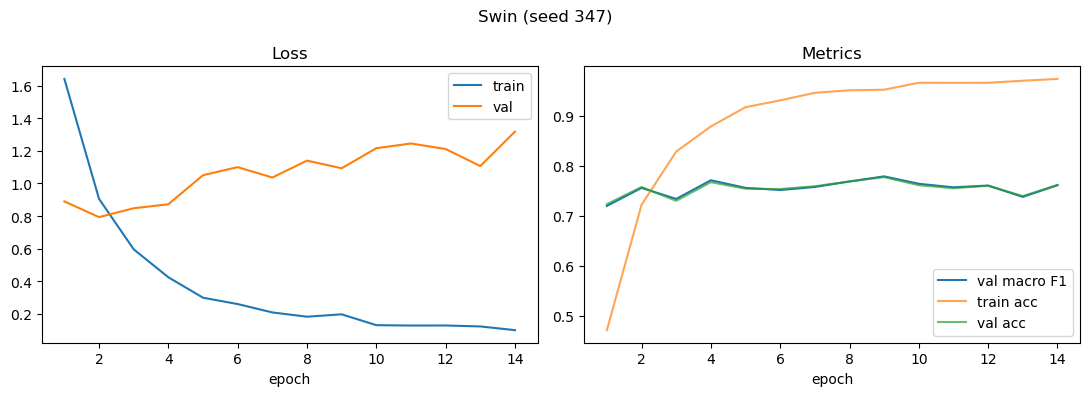


[Swin | seed 347] Test metrics: {'loss': 1.0494896157237763, 'accuracy': 0.7739656912209889, 'macro_precision': 0.7820553470699753, 'macro_recall': 0.7746418300480029, 'macro_f1': 0.7735464620801509}
[Swin | seed 347] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_347/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.666667   0.713178 0.666667 0.689139
        dressy 0.918519   0.932331 0.918519 0.925373
        ethnic 0.767442   0.818182 0.767442 0.792000
         fairy 0.958042   0.919463 0.958042 0.938356
      feminine 0.743802   0.714286 0.743802 0.728745
           gal 0.713287   0.864407 0.713287 0.781609
       girlish 0.500000   0.715517 0.500000 0.588652
kireime-casual 0.689873   0.595628 0.689873 0.639296
        lolita 0.937107   0.961290 0.937107 0.949045
          mode 0.911950   0.662100 0.911950 0.767196
       natural 0.821705   0.658385 0.821705 0.731034
         retro 0.692913   0.758621 

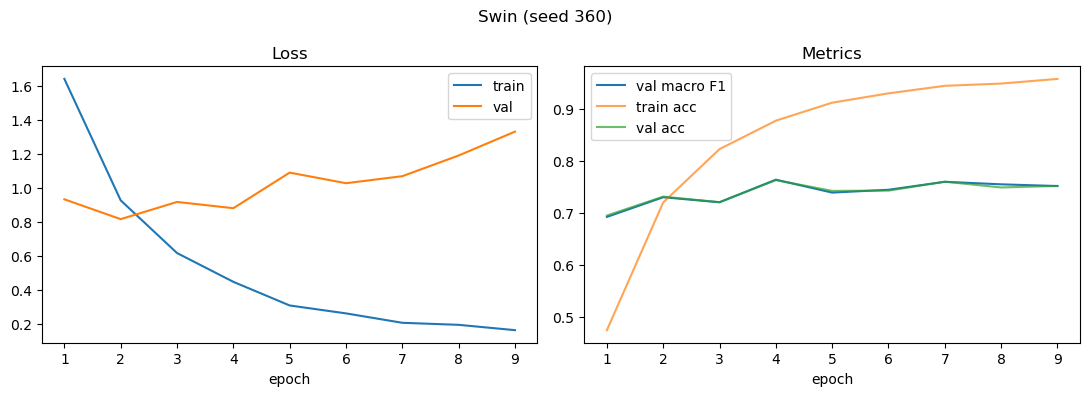


[Swin | seed 360] Test metrics: {'loss': 0.8106920201891487, 'accuracy': 0.7800201816347124, 'macro_precision': 0.7915663193425545, 'macro_recall': 0.7820275514433882, 'macro_f1': 0.7812254727465403}
[Swin | seed 360] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_360/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.652174   0.629371 0.652174 0.640569
        dressy 0.910448   0.983871 0.910448 0.945736
        ethnic 0.720930   0.902913 0.720930 0.801724
         fairy 0.930556   0.964029 0.930556 0.946996
      feminine 0.785124   0.730769 0.785124 0.756972
           gal 0.678322   0.950980 0.678322 0.791837
       girlish 0.469880   0.634146 0.469880 0.539792
kireime-casual 0.803797   0.593458 0.803797 0.682796
        lolita 0.987421   0.928994 0.987421 0.957317
          mode 0.779874   0.800000 0.779874 0.789809
       natural 0.744186   0.774194 0.744186 0.758893
         retro 0.803150   0.658065 

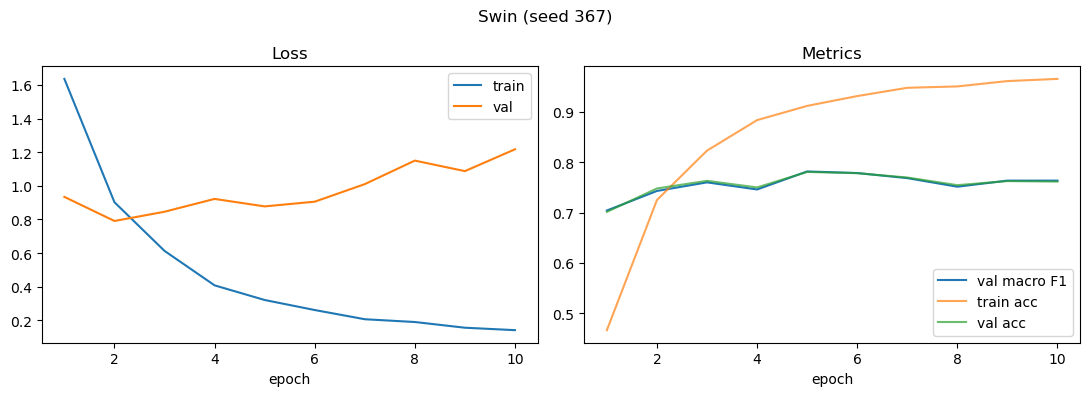


[Swin | seed 367] Test metrics: {'loss': 0.8522709427339398, 'accuracy': 0.7719475277497477, 'macro_precision': 0.7868134520825046, 'macro_recall': 0.7752084539089157, 'macro_f1': 0.7743313228070132}
[Swin | seed 367] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_367/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.673913   0.704545 0.673913 0.688889
        dressy 0.947761   0.940741 0.947761 0.944238
        ethnic 0.806202   0.776119 0.806202 0.790875
         fairy 0.895105   0.895105 0.895105 0.895105
      feminine 0.834711   0.668874 0.834711 0.742647
           gal 0.832168   0.676136 0.832168 0.746082
       girlish 0.506024   0.661417 0.506024 0.573379
kireime-casual 0.753165   0.550926 0.753165 0.636364
        lolita 0.881250   0.972414 0.881250 0.924590
          mode 0.679245   0.824427 0.679245 0.744828
       natural 0.620155   0.952381 0.620155 0.751174
         retro 0.724409   0.807018 

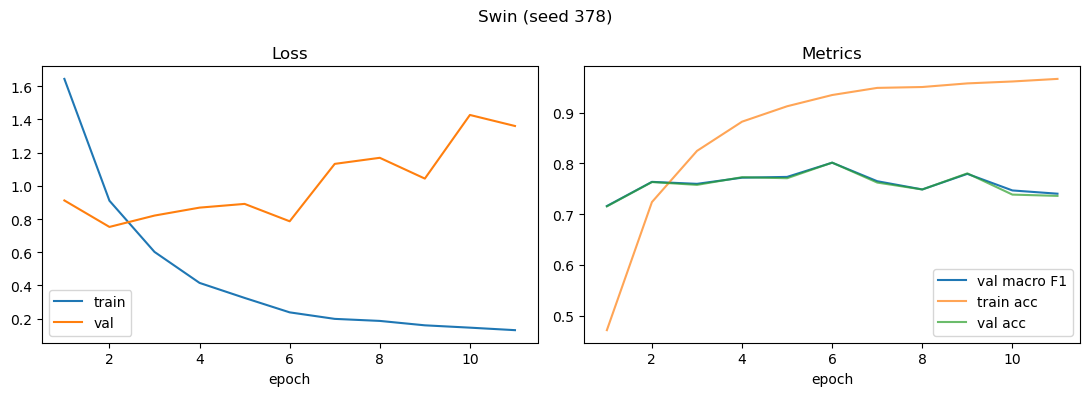


[Swin | seed 378] Test metrics: {'loss': 0.9171654994023436, 'accuracy': 0.7739656912209889, 'macro_precision': 0.7763989048138734, 'macro_recall': 0.7759558472102638, 'macro_f1': 0.7736773967983084}
[Swin | seed 378] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_378/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.717391   0.630573 0.717391 0.671186
        dressy 0.917910   0.897810 0.917910 0.907749
        ethnic 0.821705   0.834646 0.821705 0.828125
         fairy 0.958042   0.925676 0.958042 0.941581
      feminine 0.793388   0.662069 0.793388 0.721805
           gal 0.846154   0.711765 0.846154 0.773163
       girlish 0.518072   0.651515 0.518072 0.577181
kireime-casual 0.658228   0.626506 0.658228 0.641975
        lolita 0.968750   0.917160 0.968750 0.942249
          mode 0.761006   0.817568 0.761006 0.788274
       natural 0.705426   0.842593 0.705426 0.767932
         retro 0.685039   0.763158 

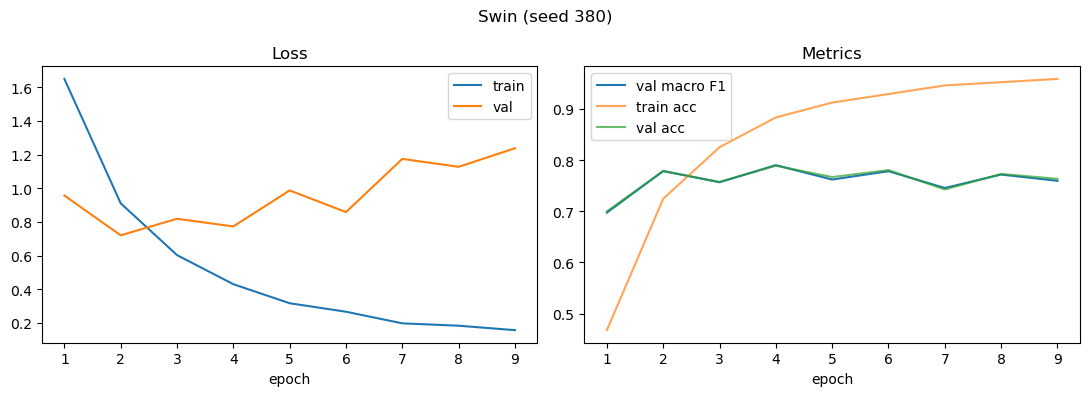


[Swin | seed 380] Test metrics: {'loss': 0.8186766017457672, 'accuracy': 0.7699293642785066, 'macro_precision': 0.7820771331995565, 'macro_recall': 0.7721504267108413, 'macro_f1': 0.7731248389679134}
[Swin | seed 380] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_380/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.795620   0.622857 0.795620 0.698718
        dressy 0.947761   0.984496 0.947761 0.965779
        ethnic 0.775194   0.862069 0.775194 0.816327
         fairy 0.854167   0.946154 0.854167 0.897810
      feminine 0.776860   0.569697 0.776860 0.657343
           gal 0.734266   0.695364 0.734266 0.714286
       girlish 0.560241   0.650350 0.560241 0.601942
kireime-casual 0.626582   0.607362 0.626582 0.616822
        lolita 0.949686   0.961783 0.949686 0.955696
          mode 0.830189   0.758621 0.830189 0.792793
       natural 0.697674   0.841121 0.697674 0.762712
         retro 0.755906   0.738462 

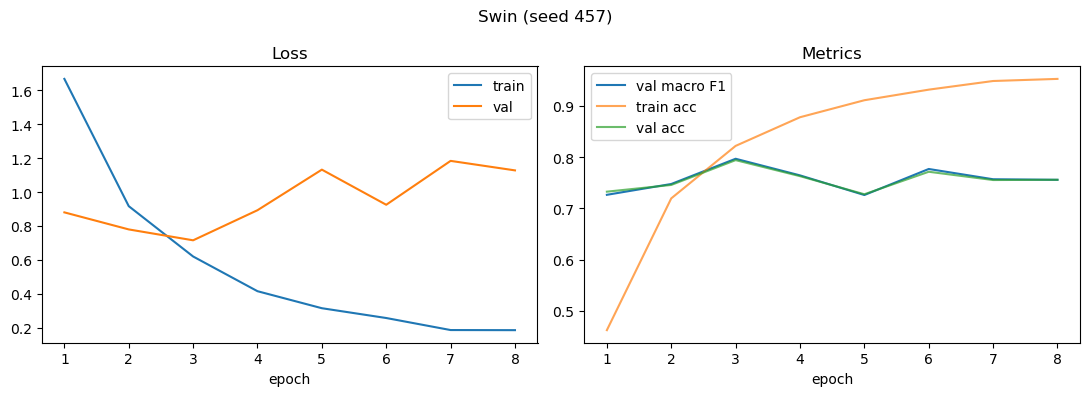


[Swin | seed 457] Test metrics: {'loss': 0.7754647353462928, 'accuracy': 0.7674066599394551, 'macro_precision': 0.7772362388902196, 'macro_recall': 0.7672185463939768, 'macro_f1': 0.7687064458203601}
[Swin | seed 457] Per-class metrics (saved to /home/sandy/Document/FusionStyle/results/image_only/swin/seed_457/per_class.csv):
         class      acc  precision   recall       f1
  conservative 0.627737   0.710744 0.627737 0.666667
        dressy 0.791045   0.990654 0.791045 0.879668
        ethnic 0.875969   0.733766 0.875969 0.798587
         fairy 0.930556   0.985294 0.930556 0.957143
      feminine 0.652893   0.774510 0.652893 0.708520
           gal 0.769231   0.705128 0.769231 0.735786
       girlish 0.614458   0.607143 0.614458 0.610778
kireime-casual 0.721519   0.587629 0.721519 0.647727
        lolita 0.987500   0.951807 0.987500 0.969325
          mode 0.729560   0.811189 0.729560 0.768212
       natural 0.852713   0.700637 0.852713 0.769231
         retro 0.677165   0.774775 

In [7]:
summary_swin = run_swin_robustness()

## 8. Overall and per-style summary (mean ± std)


In [8]:
agg_df, per_style_df = print_and_save_aggregates(summary_swin)
display(agg_df)
display(per_style_df)


OVERALL TEST METRICS (mean +/- std across seeds)
  accuracy: 0.7794 +/- 0.0099
  macro_precision: 0.7891 +/- 0.0090
  macro_recall: 0.7802 +/- 0.0101
  macro_f1: 0.7805 +/- 0.0101

Saved: /home/sandy/Document/FusionStyle/results/image_only/swin/aggregation_summary.csv

PER-STYLE TEST F1 (mean +/- std across seeds)
  conservative          F1 0.6942 +/- 0.0280
  dressy                F1 0.9401 +/- 0.0205
  ethnic                F1 0.8139 +/- 0.0329
  fairy                 F1 0.9253 +/- 0.0221
  feminine              F1 0.7292 +/- 0.0327
  gal                   F1 0.7714 +/- 0.0238
  girlish               F1 0.6148 +/- 0.0349
  kireime-casual        F1 0.6480 +/- 0.0240
  lolita                F1 0.9500 +/- 0.0104
  mode                  F1 0.7673 +/- 0.0306
  natural               F1 0.7679 +/- 0.0339
  retro                 F1 0.7160 +/- 0.0297
  rock                  F1 0.7715 +/- 0.0248
  street                F1 0.8169 +/- 0.0259

Saved: /home/sandy/Document/FusionStyle/results/imag

,metric,mean,std
0,accuracy,0.779448,0.009869
1,macro_precision,0.789100,0.009032
2,macro_recall,0.780186,0.010083
3,macro_f1,0.780468,0.010136


,style,f1_mean,f1_std,precision_mean,recall_mean,acc_mean
0,conservative,0.694228,0.027986,0.689365,0.708377,0.708377
1,dressy,0.940122,0.020500,0.953505,0.928821,0.928821
2,ethnic,0.813887,0.032864,0.828789,0.806977,0.806977
3,fairy,0.925338,0.022124,0.925563,0.927279,0.927279
4,feminine,0.729153,0.032733,0.737290,0.734711,0.734711
5,gal,0.771445,0.023838,0.791240,0.759674,0.759674
6,girlish,0.614785,0.034926,0.634909,0.606426,0.606426
7,kireime-casual,0.647954,0.024045,0.630681,0.676160,0.676160
8,lolita,0.949997,0.010400,0.944655,0.956351,0.956351
9,mode,0.767288,0.030640,0.771743,0.774004,0.774004
